In [ ]:
Github Link: https://github.com/Mohammed-Ameenulla-Kolthodi/Individual-Assignment-Machine-Learning.git

# Depth vs Width in Multilayer Perceptrons: Understanding Expressivity

In this tutorial, we explore how the *depth* (number of layers) and *width* (number of neurons per layer) of a Multilayer Perceptron (MLP) affect its expressive power.

Expressivity refers to a model’s ability to approximate complex functions. While the Universal Approximation Theorem states that a sufficiently wide single‑hidden‑layer network can approximate any continuous function, deeper networks can often represent the same functions **more efficiently**, using fewer parameters and capturing hierarchical structure.

We will demonstrate these ideas using:
- A synthetic non‑linear dataset  
- MLPs with varying depth  
- MLPs with varying width  
- Visualisations of decision boundaries  
- Comparisons of accuracy and parameter counts  

This notebook forms the experimental component of the tutorial.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.colors as mcolors


## Generating a Non‑Linear Dataset

To compare the expressive power of different MLP architectures, we need a dataset that cannot be separated by a simple linear boundary.

The **two‑moons** dataset is ideal because:
- It is inherently non‑linear  
- It is easy to visualise  
- It highlights differences in decision boundaries  
- It is small and fast to train on  

We will generate 2000 samples with moderate noise and split them into training and testing sets.


In [2]:
# Generate a synthetic dataset that highlights non-linear decision boundaries.
# The "moons" dataset is ideal for demonstrating expressivity differences.
np.random.seed(42)
X, y = make_moons(n_samples=2000, noise=0.25)

# Split into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


## Visualising Decision Boundaries

A powerful way to understand model expressivity is to visualise how the network partitions the input space.

We create a function that:
- Generates a dense grid of points  
- Classifies each point using the trained model  
- Plots the resulting decision regions  
- Overlays the original dataset  

More expressive models produce more intricate and accurate boundaries.


In [3]:
# This function visualises how a trained MLP partitions the input space.
# More expressive models produce more complex decision boundaries.
def plot_boundary(model, X, y, title, filename):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap = mcolors.ListedColormap(["#1f77b4", "#ff7f0e"])

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap, s=10)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()


## Training MLP Models with Different Architectures

To systematically compare depth and width, we define a helper function that trains an MLP with a given hidden‑layer configuration.

Examples:
- `(10,)` → 1 hidden layer with 10 neurons  
- `(10,10,10)` → 3 hidden layers with 10 neurons each  

We use:
- ReLU activation  
- Adam optimiser  
- A high iteration limit to ensure convergence  


In [4]:
# Train an MLP with a given hidden-layer configuration.
# Example: (10,10,10) means 3 hidden layers with 10 neurons each.
def train_model(hidden_layers):
    model = MLPClassifier(hidden_layer_sizes=hidden_layers,
                          activation="relu",
                          solver="adam",
                          max_iter=3000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return model, acc


# Depth Experiment: Increasing the Number of Layers

In this experiment, we fix the width at 10 neurons per layer and vary the **depth**:

- 1 layer: `(10,)`  
- 2 layers: `(10,10)`  
- 3 layers: `(10,10,10)`  
- 4 layers: `(10,10,10,10)`  

This allows us to observe how adding layers affects:
- Decision boundary complexity  
- Classification accuracy  
- Model behaviour  

Deeper networks are theoretically capable of representing certain functions exponentially more efficiently than shallow ones. We will see whether this manifests in practice on our dataset.


In [5]:
# Depth experiment: increasing number of layers while keeping width fixed.
depth_configs = [(10,), (10,10), (10,10,10), (10,10,10,10)]
depth_results = []

for cfg in depth_configs:
    model, acc = train_model(cfg)
    depth_results.append((cfg, acc))
    plot_boundary(model, X, y,
                  f"Depth: {len(cfg)} layers",
                  f"depth_{len(cfg)}.png")

depth_results


[((10,), 0.8666666666666667),
 ((10, 10), 0.94),
 ((10, 10, 10), 0.945),
 ((10, 10, 10, 10), 0.94)]

# Width Experiment: Increasing the Number of Neurons

Here, we fix the depth at a single hidden layer and vary the **width**:

- 5 neurons: `(5,)`  
- 20 neurons: `(20,)`  
- 50 neurons: `(50,)`  
- 100 neurons: `(100,)`  

This experiment shows how increasing the number of neurons affects:
- Expressivity  
- Decision boundary smoothness  
- Accuracy  

Wider networks can approximate more complex functions, but often require many more parameters than deeper networks to achieve similar expressivity.


In [6]:
# Width experiment: increasing number of neurons while keeping depth fixed.
width_configs = [(5,), (20,), (50,), (100,)]
width_results = []

for cfg in width_configs:
    model, acc = train_model(cfg)
    width_results.append((cfg, acc))
    plot_boundary(model, X, y,
                  f"Width: {cfg[0]} neurons",
                  f"width_{cfg[0]}.png")

width_results


[((5,), 0.8633333333333333),
 ((20,), 0.9366666666666666),
 ((50,), 0.94),
 ((100,), 0.94)]

## Counting Trainable Parameters

To compare depth and width fairly, we compute the total number of trainable parameters for each architecture.

This helps answer questions such as:
- Does depth or width give more expressivity per parameter?
- Are deeper networks more parameter‑efficient?
- How does model size scale with architecture choices?

We calculate parameters using:
- Weight matrices between layers  
- Bias vectors for each layer  


In [7]:
# Count total trainable parameters for a given architecture.
# This helps compare depth vs width in terms of model size.
def count_params(hidden_layers):
    layers = [2] + list(hidden_layers) + [1]  # input → hidden → output
    total = 0
    for i in range(len(layers)-1):
        total += layers[i]*layers[i+1] + layers[i+1]  # weights + biases
    return total

depth_params = [count_params(cfg) for cfg in depth_configs]
width_params = [count_params(cfg) for cfg in width_configs]

depth_params, width_params


([41, 151, 261, 371], [21, 81, 201, 401])

 Results

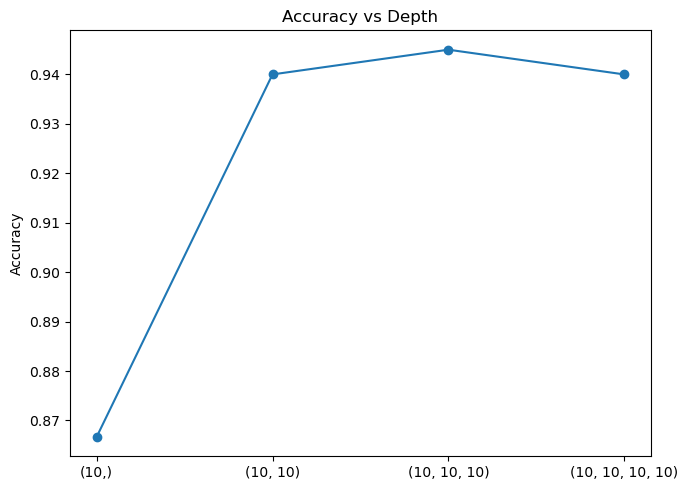

In [8]:
plt.figure(figsize=(7,5))
plt.plot(range(1,5), [acc for _,acc in depth_results], marker="o")
plt.xticks(range(1,5), [str(cfg) for cfg,_ in depth_results])
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")
plt.tight_layout()
plt.savefig("accuracy_depth.png", dpi=300)
plt.show()


## Accuracy vs Depth

This plot shows how classification accuracy changes as we increase the number of layers.

Key questions:
- Does adding layers improve performance?
- Is there a point of diminishing returns?
- How does depth affect generalisation?

We will compare the results visually.


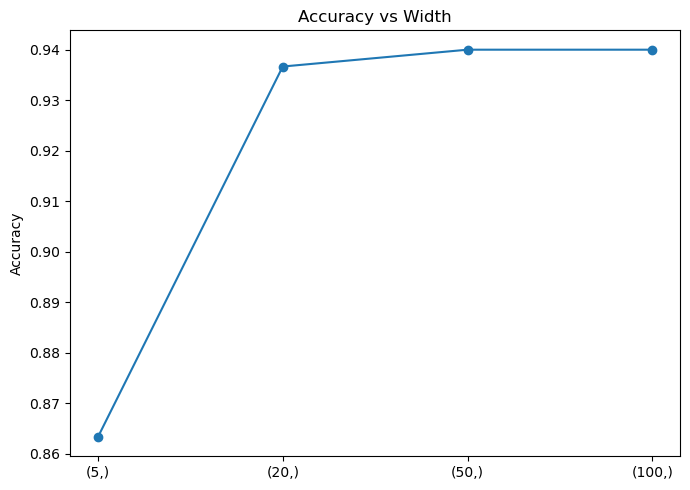

In [9]:
plt.figure(figsize=(7,5))
plt.plot(range(1,5), [acc for _,acc in width_results], marker="o")
plt.xticks(range(1,5), [str(cfg) for cfg,_ in width_results])
plt.ylabel("Accuracy")
plt.title("Accuracy vs Width")
plt.tight_layout()
plt.savefig("accuracy_width.png", dpi=300)
plt.show()


## Accuracy vs Width

This plot shows how accuracy changes as we increase the number of neurons in a single hidden layer.

This helps us understand:
- How width contributes to expressivity  
- Whether wider networks outperform deeper ones  
- How parameter count influences performance  


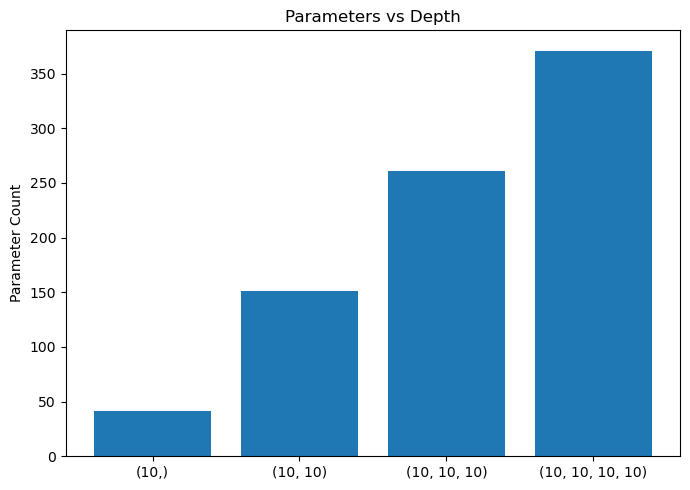

In [10]:
plt.figure(figsize=(7,5))
plt.bar(range(1,5), depth_params)
plt.xticks(range(1,5), [str(cfg) for cfg in depth_configs])
plt.ylabel("Parameter Count")
plt.title("Parameters vs Depth")
plt.tight_layout()
plt.savefig("params_depth.png", dpi=300)
plt.show()


In [ ]:
## Parameter Count vs Depth

This bar chart shows how the number of trainable parameters grows as we add more layers.

Even with fixed width, deeper networks accumulate parameters quickly.  
However, they may still be more efficient than extremely wide shallow networks.


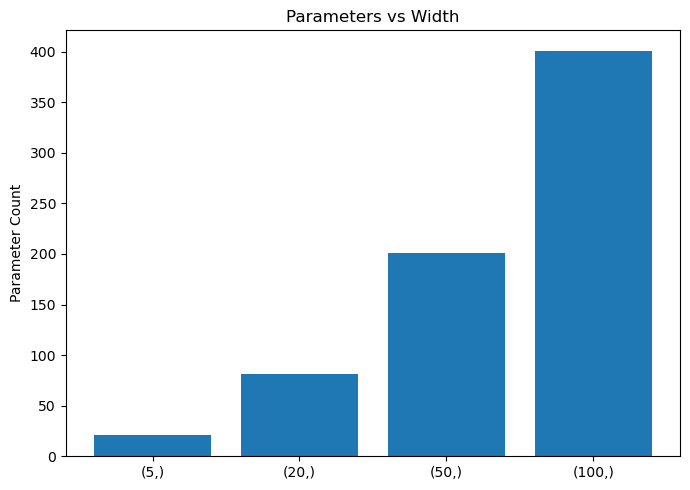

In [11]:
plt.figure(figsize=(7,5))
plt.bar(range(1,5), width_params)
plt.xticks(range(1,5), [str(cfg) for cfg in width_configs])
plt.ylabel("Parameter Count")
plt.title("Parameters vs Width")
plt.tight_layout()
plt.savefig("params_width.png", dpi=300)
plt.show()


In [ ]:
## Parameter Count vs Width

This chart shows how parameter count increases as we widen a single hidden layer.

Wider networks can become very large very quickly, which may lead to:
- Overfitting  
- Longer training times  
- Higher memory usage  

Comparing this with the depth experiment helps illustrate the depth–width tradeoff.
